# PLD 实验结果分析

读 `results/*.csv` 自动生成论文用的图表与汇总表。

**期望的输入文件**(由 `scripts/run_*.sh` 产生):

| 文件名模式 | 来源脚本 | 变量 |
|---|---|---|
| `pld_len{L}.csv` | `run_pld.sh` | 输出长度 L ∈ {64, 128, 256, 512} |
| `ablation_K{K}.csv` | `run_ablation.sh` | K ∈ {1, 2, 3, 5, 7, 10} |
| `ablation_ngram{N}.csv` | `run_ablation.sh` | max_ngram_size N ∈ {1, 2, 3, 4} |

缺失的文件会跳过对应章节,不会报错。

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
PLOTS = RESULTS / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f'results dir : {RESULTS}')
print(f'plots dir   : {PLOTS}')
print()
print('available csv files:')
for p in sorted(RESULTS.glob('*.csv')):
    print(f'  {p.name}')

results dir : D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results
plots dir   : D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results\plots

available csv files:
  ablation_K1.csv
  ablation_K10.csv
  ablation_K2.csv
  ablation_K3.csv
  ablation_K5.csv
  ablation_K7.csv
  ablation_ngram1.csv
  ablation_ngram2.csv
  ablation_ngram3.csv
  ablation_ngram4.csv
  benchmark.csv
  pld_len128.csv
  pld_len256.csv
  pld_len512.csv
  pld_len64.csv
  summary.csv


In [2]:
def load_csvs(pattern, parse_variant=None):
    """加载匹配 pattern 的所有 CSV,合并成一张表。

    parse_variant(filename) -> dict 用来从文件名抽取额外的实验变量
    (因为像 max_ngram_size 这种没写进 CSV 列里)。
    """
    rows = []
    for path in sorted(RESULTS.glob(pattern)):
        df = pd.read_csv(path)
        if parse_variant is not None:
            for k, v in parse_variant(path.name).items():
                df[k] = v
        df['source_file'] = path.name
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def add_speedup(df, group_cols):
    """在 df 内按 group_cols 分组,把 baseline 的 tpot 当基准算每行 speedup。"""
    if df.empty:
        return df
    base = (df[df['method'] == 'baseline']
            .set_index(group_cols)['tpot_mean_ms']
            .rename('base_tpot'))
    out = df.merge(base, left_on=group_cols, right_index=True, how='left')
    out['speedup'] = out['base_tpot'] / out['tpot_mean_ms']
    return out

## 1. 输出长度扫描

**论文叙事**:Pythia-70M 单步 forward 极快,只有在长输出场景下,KV cache 复用与并行验证带来的加速才显著。

In [3]:
def parse_len(name):
    m = re.search(r'pld_len(\d+)\.csv', name)
    return {'max_new_tokens': int(m.group(1))} if m else {}

df_len = load_csvs('pld_len*.csv', parse_len)
df_len = add_speedup(df_len, ['prompt_idx', 'max_new_tokens'])
df_len.head()

,prompt_idx,method,K,prompt_len,n_generated,ttft_mean_ms,ttft_std_ms,tpot_mean_ms,tpot_std_ms,throughput_mean,throughput_std,acceptance_mean,max_new_tokens,source_file,base_tpot,speedup
0,0,baseline,0,27,128,2.9580,0.2192,2.5049,0.0191,399.2472,3.0484,0.000000,128,pld_len128.csv,2.5049,1.000000
1,0,pld_K5,5,27,128,2.8451,0.2314,1.5472,0.0337,646.6367,14.2020,0.915094,128,pld_len128.csv,2.5049,1.618989
2,1,baseline,0,78,128,2.9714,0.1655,2.4257,0.0251,412.2890,4.2760,0.000000,128,pld_len128.csv,2.4257,1.000000
3,1,pld_K5,5,78,128,2.8097,0.0305,2.9423,0.0398,339.9372,4.6360,0.502924,128,pld_len128.csv,2.4257,0.824423
4,2,baseline,0,53,128,2.9428,0.2301,2.4181,0.0248,413.5964,4.2730,0.000000,128,pld_len128.csv,2.4181,1.000000


saved -> D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results\plots\fig_output_length.png


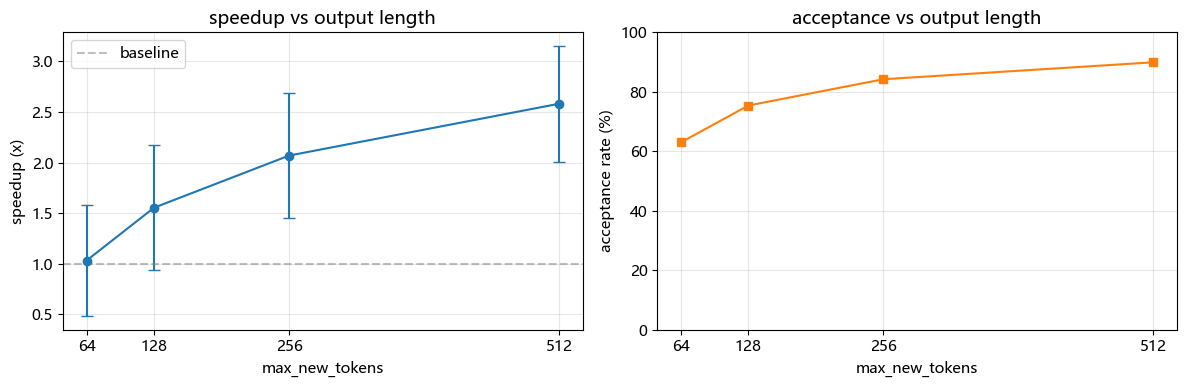

,max_new_tokens,speedup_mean,speedup_std,accept_mean
0,64,1.029293,0.549036,0.629680
1,128,1.552742,0.617267,0.753765
2,256,2.068503,0.617196,0.842175
3,512,2.581611,0.573026,0.899187


In [4]:
if df_len.empty:
    print('skip: 未找到 pld_len*.csv,先跑 scripts/run_pld.sh')
else:
    pld = df_len[df_len['method'].str.startswith('pld')]
    g = (pld.groupby('max_new_tokens')
            .agg(speedup_mean=('speedup', 'mean'),
                 speedup_std=('speedup', 'std'),
                 accept_mean=('acceptance_mean', 'mean'))
            .reset_index())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].errorbar(g['max_new_tokens'], g['speedup_mean'],
                     yerr=g['speedup_std'].fillna(0),
                     marker='o', capsize=4, color='tab:blue')
    axes[0].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='baseline')
    axes[0].set_xlabel('max_new_tokens')
    axes[0].set_ylabel('speedup (x)')
    axes[0].set_title('speedup vs output length')
    axes[0].set_xticks(g['max_new_tokens'])
    axes[0].legend()

    axes[1].plot(g['max_new_tokens'], g['accept_mean'] * 100,
                 marker='s', color='tab:orange')
    axes[1].set_xlabel('max_new_tokens')
    axes[1].set_ylabel('acceptance rate (%)')
    axes[1].set_title('acceptance vs output length')
    axes[1].set_xticks(g['max_new_tokens'])
    axes[1].set_ylim(0, 100)

    plt.tight_layout()
    out = PLOTS / 'fig_output_length.png'
    plt.savefig(out, bbox_inches='tight')
    print(f'saved -> {out}')
    plt.show()
    display(g)

## 2. K 值扫描

**论文叙事**:K 太小则草稿不够长,加速受限;K 太大则即使被拒也付出了多算的算力,反而拖慢。最优 K 一般在 3~7 之间。

In [5]:
def parse_K(name):
    m = re.search(r'ablation_K(\d+)\.csv', name)
    return {'K_label': int(m.group(1))} if m else {}

df_K = load_csvs('ablation_K*.csv', parse_K)
df_K = add_speedup(df_K, ['prompt_idx', 'K_label'])
df_K.head()

,prompt_idx,method,K,prompt_len,n_generated,ttft_mean_ms,ttft_std_ms,tpot_mean_ms,tpot_std_ms,throughput_mean,throughput_std,acceptance_mean,K_label,source_file,base_tpot,speedup
0,0,baseline,0,27,256,2.7161,0.1984,2.3517,0.0290,425.2843,5.1916,0.000000,1,ablation_K1.csv,2.3517,1.000000
1,0,pld_K1,1,27,256,2.6195,0.1588,2.1372,0.0121,467.9220,2.6383,0.975610,1,ablation_K1.csv,2.3517,1.100365
2,1,baseline,0,78,256,2.8368,0.1828,2.4137,0.0086,414.3018,1.4867,0.000000,1,ablation_K1.csv,2.4137,1.000000
3,1,pld_K1,1,78,256,2.7328,0.0683,2.8653,0.0190,349.0235,2.3271,0.878788,1,ablation_K1.csv,2.4137,0.842390
4,2,baseline,0,53,256,2.6999,0.1168,2.4442,0.0043,409.1262,0.7253,0.000000,1,ablation_K1.csv,2.4442,1.000000


saved -> D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results\plots\fig_K_sweep.png


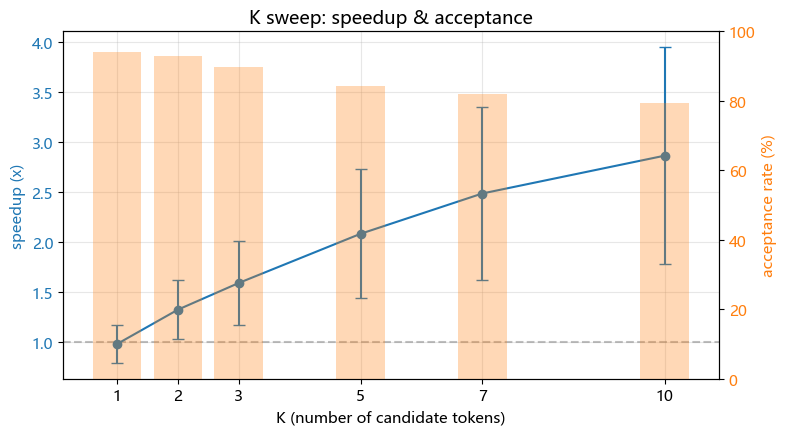

,K_label,speedup_mean,speedup_std,accept_mean
0,1,0.979846,0.189420,0.941870
1,2,1.323153,0.295980,0.928991
2,3,1.589923,0.420376,0.897294
3,5,2.081283,0.645300,0.842175
4,7,2.484276,0.868984,0.818886
5,10,2.862870,1.084851,0.794493



best K = 10: speedup=2.86x, accept=79.4%


In [6]:
if df_K.empty:
    print('skip: 未找到 ablation_K*.csv,先跑 scripts/run_ablation.sh')
else:
    pld = df_K[df_K['method'].str.startswith('pld')]
    g = (pld.groupby('K_label')
            .agg(speedup_mean=('speedup', 'mean'),
                 speedup_std=('speedup', 'std'),
                 accept_mean=('acceptance_mean', 'mean'))
            .reset_index())

    fig, ax1 = plt.subplots(figsize=(8, 4.5))

    color1 = 'tab:blue'
    ax1.errorbar(g['K_label'], g['speedup_mean'],
                 yerr=g['speedup_std'].fillna(0),
                 marker='o', capsize=4, color=color1, label='speedup')
    ax1.set_xlabel('K (number of candidate tokens)')
    ax1.set_ylabel('speedup (x)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xticks(g['K_label'])

    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.bar(g['K_label'], g['accept_mean'] * 100,
            alpha=0.3, color=color2, label='acceptance')
    ax2.set_ylabel('acceptance rate (%)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 100)
    ax2.grid(False)

    plt.title('K sweep: speedup & acceptance')
    plt.tight_layout()
    out = PLOTS / 'fig_K_sweep.png'
    plt.savefig(out, bbox_inches='tight')
    print(f'saved -> {out}')
    plt.show()
    display(g)

    best = g.loc[g['speedup_mean'].idxmax()]
    print(f"\nbest K = {int(best['K_label'])}: speedup={best['speedup_mean']:.2f}x, accept={best['accept_mean']*100:.1f}%")

## 3. n-gram 大小扫描

**论文叙事**:n=1 匹配特别多但语义弱(接受率低),n 太大匹配少(没草稿可用)。直观上 n=2 或 3 是甜点。

In [7]:
def parse_ngram(name):
    m = re.search(r'ablation_ngram(\d+)\.csv', name)
    return {'max_ngram_size': int(m.group(1))} if m else {}

df_ng = load_csvs('ablation_ngram*.csv', parse_ngram)
df_ng = add_speedup(df_ng, ['prompt_idx', 'max_ngram_size'])
df_ng.head()

,prompt_idx,method,K,prompt_len,n_generated,ttft_mean_ms,ttft_std_ms,tpot_mean_ms,tpot_std_ms,throughput_mean,throughput_std,acceptance_mean,max_ngram_size,source_file,base_tpot,speedup
0,0,baseline,0,27,256,2.9411,0.1421,2.4488,0.0116,408.3701,1.9246,0.000000,1,ablation_ngram1.csv,2.4488,1.000000
1,0,pld_K5,5,27,256,2.7795,0.1441,0.8510,0.0107,1175.2423,14.8651,0.957346,1,ablation_ngram1.csv,2.4488,2.877556
2,1,baseline,0,78,256,2.8091,0.2129,2.4557,0.0111,407.2186,1.8411,0.000000,1,ablation_ngram1.csv,2.4557,1.000000
3,1,pld_K5,5,78,256,2.9778,0.3477,1.1767,0.0441,851.0104,31.2430,0.641892,1,ablation_ngram1.csv,2.4557,2.086938
4,2,baseline,0,53,256,3.1168,0.1284,2.4772,0.0057,403.6837,0.9364,0.000000,1,ablation_ngram1.csv,2.4772,1.000000


saved -> D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results\plots\fig_ngram_sweep.png


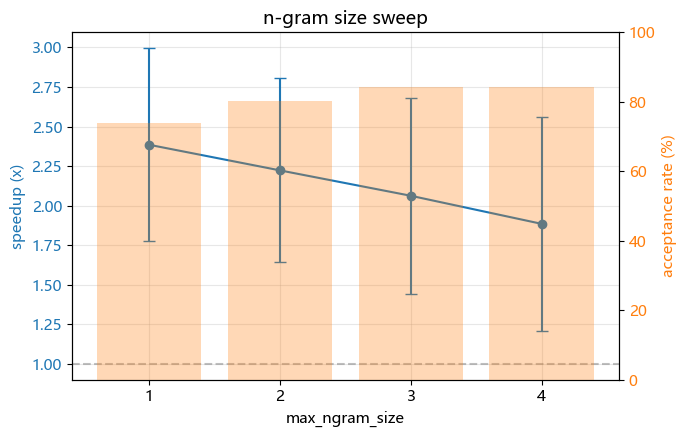

,max_ngram_size,speedup_mean,speedup_std,accept_mean
0,1,2.384912,0.611156,0.738537
1,2,2.222891,0.581647,0.800809
2,3,2.062302,0.619403,0.842175
3,4,1.884680,0.674726,0.841466


In [8]:
if df_ng.empty:
    print('skip: 未找到 ablation_ngram*.csv')
else:
    pld = df_ng[df_ng['method'].str.startswith('pld')]
    g = (pld.groupby('max_ngram_size')
            .agg(speedup_mean=('speedup', 'mean'),
                 speedup_std=('speedup', 'std'),
                 accept_mean=('acceptance_mean', 'mean'))
            .reset_index())

    fig, ax1 = plt.subplots(figsize=(7, 4.5))

    color1 = 'tab:blue'
    ax1.errorbar(g['max_ngram_size'], g['speedup_mean'],
                 yerr=g['speedup_std'].fillna(0),
                 marker='o', capsize=4, color=color1)
    ax1.set_xlabel('max_ngram_size')
    ax1.set_ylabel('speedup (x)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xticks(g['max_ngram_size'])

    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.bar(g['max_ngram_size'], g['accept_mean'] * 100,
            alpha=0.3, color=color2)
    ax2.set_ylabel('acceptance rate (%)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 100)
    ax2.grid(False)

    plt.title('n-gram size sweep')
    plt.tight_layout()
    out = PLOTS / 'fig_ngram_sweep.png'
    plt.savefig(out, bbox_inches='tight')
    print(f'saved -> {out}')
    plt.show()
    display(g)

## 4. 不同文本类型的接受率

**论文叙事**:PLD 的有效性依赖 prompt 内重复模式。重复明显的句子 / 代码模板接受率最高,纯叙述文本最低 —— 这恰好解释了 PLD 在长文档摘要 / 代码补全场景的天然优势。

saved -> D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results\plots\fig_per_prompt.png


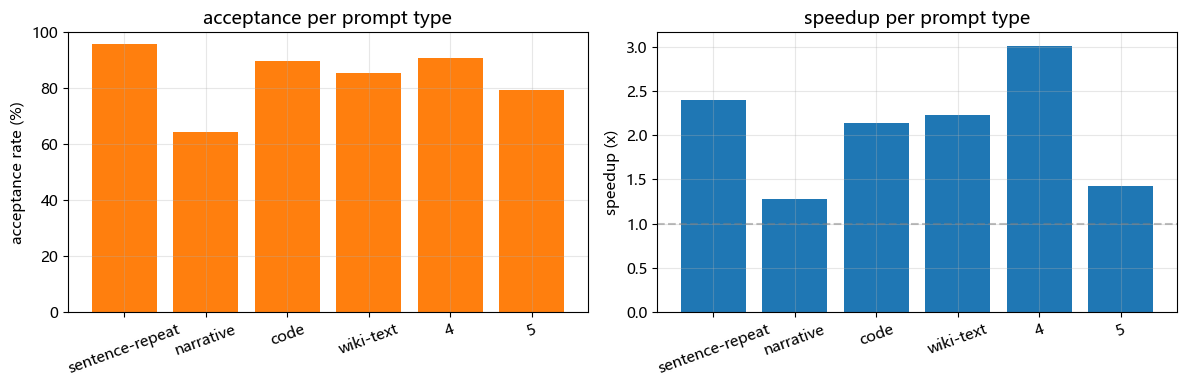

,prompt_label,prompt_len,acceptance_mean,speedup
49,sentence-repeat,27,0.957346,2.399881
51,narrative,78,0.641892,1.275648
53,code,53,0.897872,2.143396
55,wiki-text,44,0.854167,2.231840
57,4,1,0.909091,3.014502
59,5,74,0.792683,1.422430


In [9]:
PROMPT_LABELS = {
    0: 'sentence-repeat',
    1: 'narrative',
    2: 'code',
    3: 'wiki-text',
}

src = pd.DataFrame()
if not df_K.empty:
    src = df_K[(df_K['method'] == 'pld_K5') & (df_K['K_label'] == 5)].copy()
if src.empty and not df_len.empty:
    src = df_len[(df_len['max_new_tokens'] == 256) & df_len['method'].str.startswith('pld')].copy()

if src.empty:
    print('skip: 没有 K=5 的数据')
else:
    src['prompt_label'] = src['prompt_idx'].map(PROMPT_LABELS).fillna(src['prompt_idx'].astype(str))
    src = src.sort_values('prompt_idx')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(src['prompt_label'], src['acceptance_mean'] * 100, color='tab:orange')
    axes[0].set_ylabel('acceptance rate (%)')
    axes[0].set_title('acceptance per prompt type')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].set_ylim(0, 100)

    axes[1].bar(src['prompt_label'], src['speedup'], color='tab:blue')
    axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_ylabel('speedup (x)')
    axes[1].set_title('speedup per prompt type')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    out = PLOTS / 'fig_per_prompt.png'
    plt.savefig(out, bbox_inches='tight')
    print(f'saved -> {out}')
    plt.show()
    display(src[['prompt_label', 'prompt_len', 'acceptance_mean', 'speedup']])

## 5. 论文用汇总表

把上面三组扫描汇成一张表,直接复制到论文 Experiments 章节。

In [10]:
def make_summary(df, group_col, label):
    if df.empty:
        return pd.DataFrame()
    pld = df[df['method'].str.startswith('pld')]
    g = (pld.groupby(group_col)
            .agg(prompt_len=('prompt_len', 'mean'),
                 baseline_tpot_ms=('base_tpot', 'mean'),
                 pld_tpot_ms=('tpot_mean_ms', 'mean'),
                 speedup=('speedup', 'mean'),
                 acceptance=('acceptance_mean', 'mean'))
            .round(3)
            .reset_index())
    g.insert(0, 'sweep', label)
    return g

tables = [
    make_summary(df_len, 'max_new_tokens', 'output_length'),
    make_summary(df_K, 'K_label', 'K'),
    make_summary(df_ng, 'max_ngram_size', 'ngram_size'),
]
summary = pd.concat([t for t in tables if not t.empty], ignore_index=True) if tables else pd.DataFrame()
summary

,sweep,max_new_tokens,prompt_len,baseline_tpot_ms,pld_tpot_ms,speedup,acceptance,K_label,max_ngram_size
0,output_length,64.0,46.167,2.517,3.175,1.029,0.630,NaN,NaN
1,output_length,128.0,46.167,2.446,1.837,1.553,0.754,NaN,NaN
2,output_length,256.0,46.167,2.457,1.286,2.069,0.842,NaN,NaN
3,output_length,512.0,46.167,2.476,0.996,2.582,0.899,NaN,NaN
4,K,NaN,46.167,2.443,2.570,0.980,0.942,1.0,NaN
5,K,NaN,46.167,2.450,1.921,1.323,0.929,2.0,NaN
6,K,NaN,46.167,2.439,1.625,1.590,0.897,3.0,NaN
7,K,NaN,46.167,2.449,1.285,2.081,0.842,5.0,NaN
8,K,NaN,46.167,2.578,1.170,2.484,0.819,7.0,NaN
9,K,NaN,46.167,2.436,0.987,2.863,0.794,10.0,NaN


In [11]:
if summary.empty:
    print('skip: 没有可汇总的数据')
else:
    out_md = RESULTS / 'summary.md'
    out_csv = RESULTS / 'summary.csv'
    out_md.write_text(summary.to_markdown(index=False), encoding='utf-8')
    summary.to_csv(out_csv, index=False)
    print(f'saved -> {out_md}')
    print(f'saved -> {out_csv}')

saved -> D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results\summary.md
saved -> D:\My_Study\sophomore\AI_basis\NLP\spec-decoding-pythia\results\summary.csv


## 6. 一句话结论

下面这个 cell 自动生成可塞进论文 Conclusion / README 的一句话总结。

In [12]:
lines = []
if not df_len.empty:
    pld = df_len[df_len['method'].str.startswith('pld')]
    g = pld.groupby('max_new_tokens')['speedup'].mean()
    sp_min, sp_max = g.min(), g.max()
    lines.append(f'Output length sweep: speedup ranges {sp_min:.2f}x ~ {sp_max:.2f}x (longer output, higher speedup).')
if not df_K.empty:
    pld = df_K[df_K['method'].str.startswith('pld')]
    g = pld.groupby('K_label')['speedup'].mean()
    best_K = int(g.idxmax())
    lines.append(f'K sweep: best K={best_K}, speedup={g.max():.2f}x.')
if not df_ng.empty:
    pld = df_ng[df_ng['method'].str.startswith('pld')]
    g = pld.groupby('max_ngram_size')['speedup'].mean()
    best_n = int(g.idxmax())
    lines.append(f'n-gram sweep: best n={best_n}, speedup={g.max():.2f}x.')

if lines:
    print('\n'.join(lines))
else:
    print('no data - run scripts/run_pld.sh and scripts/run_ablation.sh first')

Output length sweep: speedup ranges 1.03x ~ 2.58x (longer output, higher speedup).
K sweep: best K=10, speedup=2.86x.
n-gram sweep: best n=1, speedup=2.38x.
